Notebook para modelo de Red neuronal

In [11]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [12]:
# df = pd.read_csv("../../data/processed/.csv")
df = pd.read_csv("../../data/raw/dataset_practica_final.csv")

In [13]:
categorical_columns = ["hotel", "arrival_date_month", "meal", "country", "market_segment", "distribution_channel", "is_repeated_guest", "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type"]
numerical_columns = ["lead_time", "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled", "booking_changes", "agent", "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests"]                                  

In [14]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [16]:
X = df.drop(columns=["is_canceled", "company", "reservation_status", "reservation_status_date"])
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [17]:
X_train_preprocessed.shape

(95512, 253)

In [20]:
X_test_preprocessed.shape

(23878, 253)

In [22]:
dict_parametros = {
    'max_depth': [5, 10, 20, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt_cv = GridSearchCV(estimator=modelo_dt, param_grid=dict_parametros, cv=5, scoring='accuracy')
modelo_dt_cv.fit(X_train_preprocessed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_leaf': [1, 4],
                         'min_samples_split': [2, 10]},
             scoring='accuracy')

In [23]:
print(f"Mejores hiperparámetros encontrados: {modelo_dt_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_dt_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score obtenido: 86.28%


In [25]:
modelo_dt = DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_leaf=1, min_samples_split=2)
modelo_dt.fit(X_train_preprocessed, y_train)

DecisionTreeClassifier(max_depth=20)

In [26]:
y_pred = modelo_dt.predict(X_test_preprocessed)

In [27]:
y_proba = modelo_dt.predict_proba(X_test_preprocessed)[:, 1]

In [28]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  86.39%
Precisión: 82.04%
Recall:    0.81
F1-Score:  0.82
AUC:       0.91



In [29]:
# Gracias a la función classification_report podemos obtener un reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     15033
           1       0.82      0.81      0.82      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878



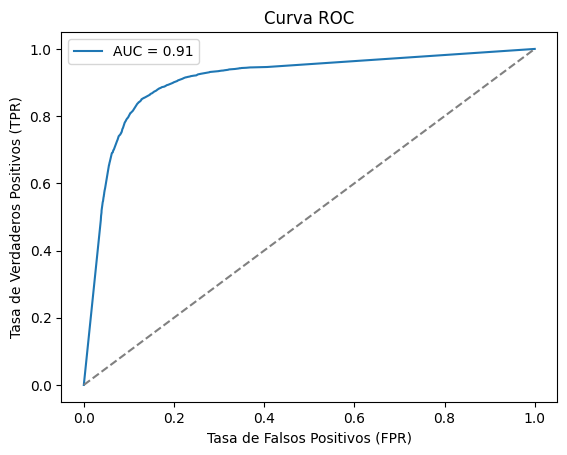

In [30]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

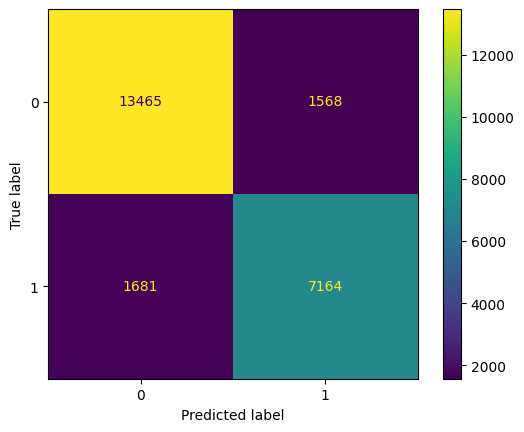

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)